            mean       std    min  25% Quartile  50% (Median)  75% Quartile  \
Oil     0.983554  5.324071 -22.81       -1.9900          1.11        4.0725   
Banks   1.596942  5.465515 -24.08       -1.6450          1.99        4.8200   
Txtls   0.231901  5.491091 -17.04       -2.8700          0.44        3.5875   
Toys    0.668760  6.418128 -18.35       -3.6975          1.14        4.6175   
Rtail   1.149793  5.545698 -21.59       -2.1375          1.18        4.5500   
Mkt-RF  1.018926  3.995827 -16.05       -1.7000          1.33        3.6600   
SMB    -0.136116  2.898537  -7.13       -2.1700         -0.05        1.7000   
HML    -0.004959  2.592366  -7.66       -1.7700         -0.09        1.5600   
RMW     0.138182  1.773253  -8.00       -0.6600          0.23        1.1000   
CMA     0.051901  2.076192  -6.41       -1.0000         -0.12        1.3900   

          max  
Oil     21.73  
Banks   22.25  
Txtls   14.87  
Toys    17.84  
Rtail   22.30  
Mkt-RF  10.86  
SMB      9.19  
HM

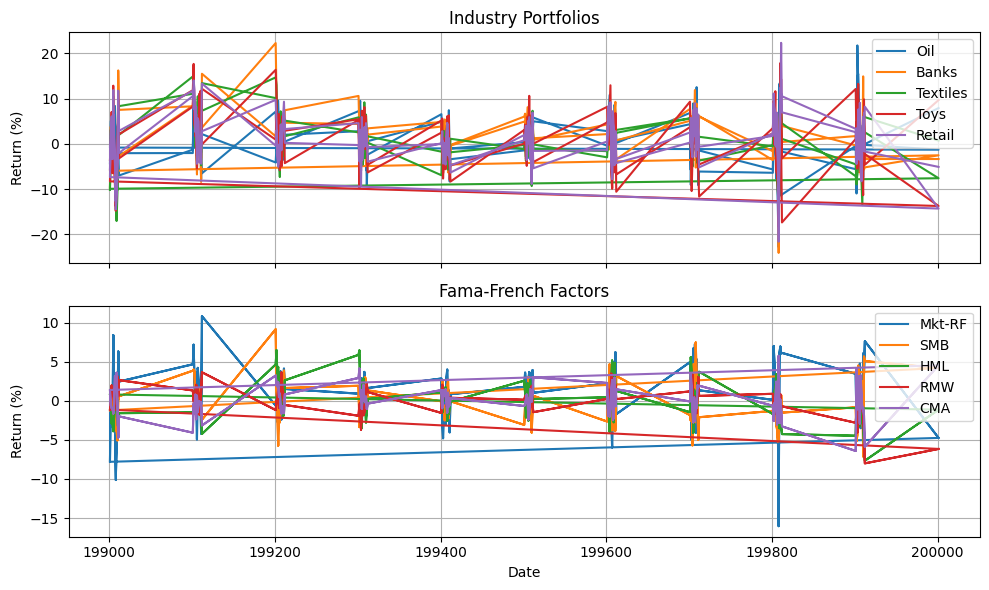

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
#Setting the start and end date
start=  199001
end=    200001
# Load the CSV
returns = pd.read_csv('49_Industry_Portfolios.csv', skiprows=11, engine='python', on_bad_lines='skip')
FF5=pd.read_csv('F-F_Research_Data_5_Factors_2x3.csv', skiprows=4, engine='python', on_bad_lines='skip')

# Rename the first column to 'Date'
returns = returns.rename(columns={returns.columns[0]: 'Date'})
FF5 = FF5.rename(columns={FF5.columns[0]: 'Date'})

#Cleaning up the column strings to remove white space
returns.columns = returns.columns.str.strip()
FF5.columns = FF5.columns.str.strip()

# Choosing which industries to use
keep_cols = ['Date', 'Oil', 'Banks', 'Txtls', 'Toys', 'Rtail']

# Only keep the chosen industry returns
returns = returns[keep_cols]

# Removing the unused rows
returns = returns.iloc[:2402].reset_index(drop=True)
FF5 = FF5.iloc[:756].reset_index(drop=True)


# Merge the data
data = pd.merge(returns, FF5, on='Date', how='inner')

# Change data type to numeric
data = data.apply(pd.to_numeric, errors='coerce')

#Using only the years we want
filtered_data = data[data["Date"].between(start, end)]

#
desc_stats = pd.DataFrame(
    {
        'mean': filtered_data.drop(columns=['Date',"RF"]).mean(),
        'std': filtered_data.drop(columns=['Date',"RF"]).std(),
        'min': filtered_data.drop(columns=['Date',"RF"]).min(),
        '25% Quartile': filtered_data.drop(columns=['Date',"RF"]).quantile(0.25),
        '50% (Median)': filtered_data.drop(columns=['Date',"RF"]).median(),
        '75% Quartile': filtered_data.drop(columns=['Date',"RF"]).quantile(0.75),
        'max': filtered_data.drop(columns=['Date',"RF"]).max(),
    }
)

print(desc_stats)

# Create 2 subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 1. Plot 5 Industry Portfolios
ax1.plot(filtered_data["Date"], filtered_data["Oil"], label="Oil")
ax1.plot(filtered_data["Date"], filtered_data["Banks"], label="Banks")
ax1.plot(filtered_data["Date"], filtered_data["Txtls"], label="Textiles")
ax1.plot(filtered_data["Date"], filtered_data["Toys"], label="Toys")
ax1.plot(filtered_data["Date"], filtered_data["Rtail"], label="Retail")

ax1.set_title("Industry Portfolios")
ax1.set_ylabel("Return (%)")
ax1.legend(loc="upper right")
ax1.grid(True)

# 2. Plot Fama-French Factors
ax2.plot(filtered_data["Date"], filtered_data["Mkt-RF"], label="Mkt-RF")
ax2.plot(filtered_data["Date"], filtered_data["SMB"], label="SMB")
ax2.plot(filtered_data["Date"], filtered_data["HML"], label="HML")
ax2.plot(filtered_data["Date"], filtered_data["RMW"], label="RMW")
ax2.plot(filtered_data["Date"], filtered_data["CMA"], label="CMA")


ax2.set_title("Fama-French Factors")
ax2.set_xlabel("Date")
ax2.set_ylabel("Return (%)")
ax2.legend(loc="upper right")
ax2.grid(True)

# Adjust layout and display
plt.tight_layout()
plt.show()

Yes this graph is an ugly mess. Lets discuss what to do with the time series 

In [84]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

Dropping duplicates/only keeping value-weighted data

In [85]:
returns = returns.drop_duplicates(
    subset="Date",
    keep="first"
)

print("Duplicate dates:", returns["Date"].duplicated().sum())

Duplicate dates: 0


In [86]:


industries = [
    "Oil",
    "Banks",
    "Txtls",
    "Toys",
    "Rtail"
]

# Select only the date and five industries
q2_data = returns[
    ["Date"] + industries
].copy()

# Convert the CSV values to numeric
q2_data = q2_data.apply(
    pd.to_numeric,
    errors="coerce"
)

# Remove rows without a valid date
q2_data = q2_data.dropna(
    subset=["Date"]
)

q2_data["Date"] = (
    q2_data["Date"]
    .astype(int)
)

# Keep only valid monthly YYYYMM dates
month_number = q2_data["Date"] % 100

q2_data = q2_data[
    month_number.between(1, 12)
].copy()

# The first occurrence is from the value-weighted section
q2_data = q2_data.drop_duplicates(
    subset="Date",
    keep="first"
)

# Put observations in chronological order
q2_data = (
    q2_data
    .sort_values("Date")
    .reset_index(drop=True)
)

# Verify the result
print(
    "Duplicate dates:",
    q2_data["Date"].duplicated().sum()
)

print(
    "Number of monthly observations:",
    len(q2_data)
)

print(
    "Sample:",
    q2_data["Date"].min(),
    "to",
    q2_data["Date"].max()
)

display(q2_data.head())
display(q2_data.tail())

Duplicate dates: 0
Number of monthly observations: 1200
Sample: 192607 to 202606


,Date,Oil,Banks,Txtls,Toys,Rtail
0,192607,-1.35,4.61,0.50,8.65,0.08
1,192608,3.64,10.71,7.83,16.81,-0.76
2,192609,-3.59,-1.80,2.30,8.33,0.25
3,192610,-1.04,-11.93,0.99,-1.40,-2.19
4,192611,0.05,-2.02,3.19,0.00,6.54


,Date,Oil,Banks,Txtls,Toys,Rtail
1195,202602,8.84,-4.29,4.47,1.11,-3.60
1196,202603,13.09,-2.53,-19.29,-9.25,-2.95
1197,202604,-4.16,8.40,8.62,5.41,13.75
1198,202605,-6.16,-2.28,4.18,-1.35,-2.67
1199,202606,-5.69,8.33,14.77,2.70,-5.59


In [87]:
q2_data["Datetime"] = pd.to_datetime(
    q2_data["Date"].astype(str),
    format="%Y%m"
)

q2_data = q2_data.set_index(
    "Datetime"
)

display(q2_data.head())

,Date,Oil,Banks,Txtls,Toys,Rtail
Datetime,,,,,,
1926-07-01,192607,-1.35,4.61,0.50,8.65,0.08
1926-08-01,192608,3.64,10.71,7.83,16.81,-0.76
1926-09-01,192609,-3.59,-1.80,2.30,8.33,0.25
1926-10-01,192610,-1.04,-11.93,0.99,-1.40,-2.19
1926-11-01,192611,0.05,-2.02,3.19,0.00,6.54


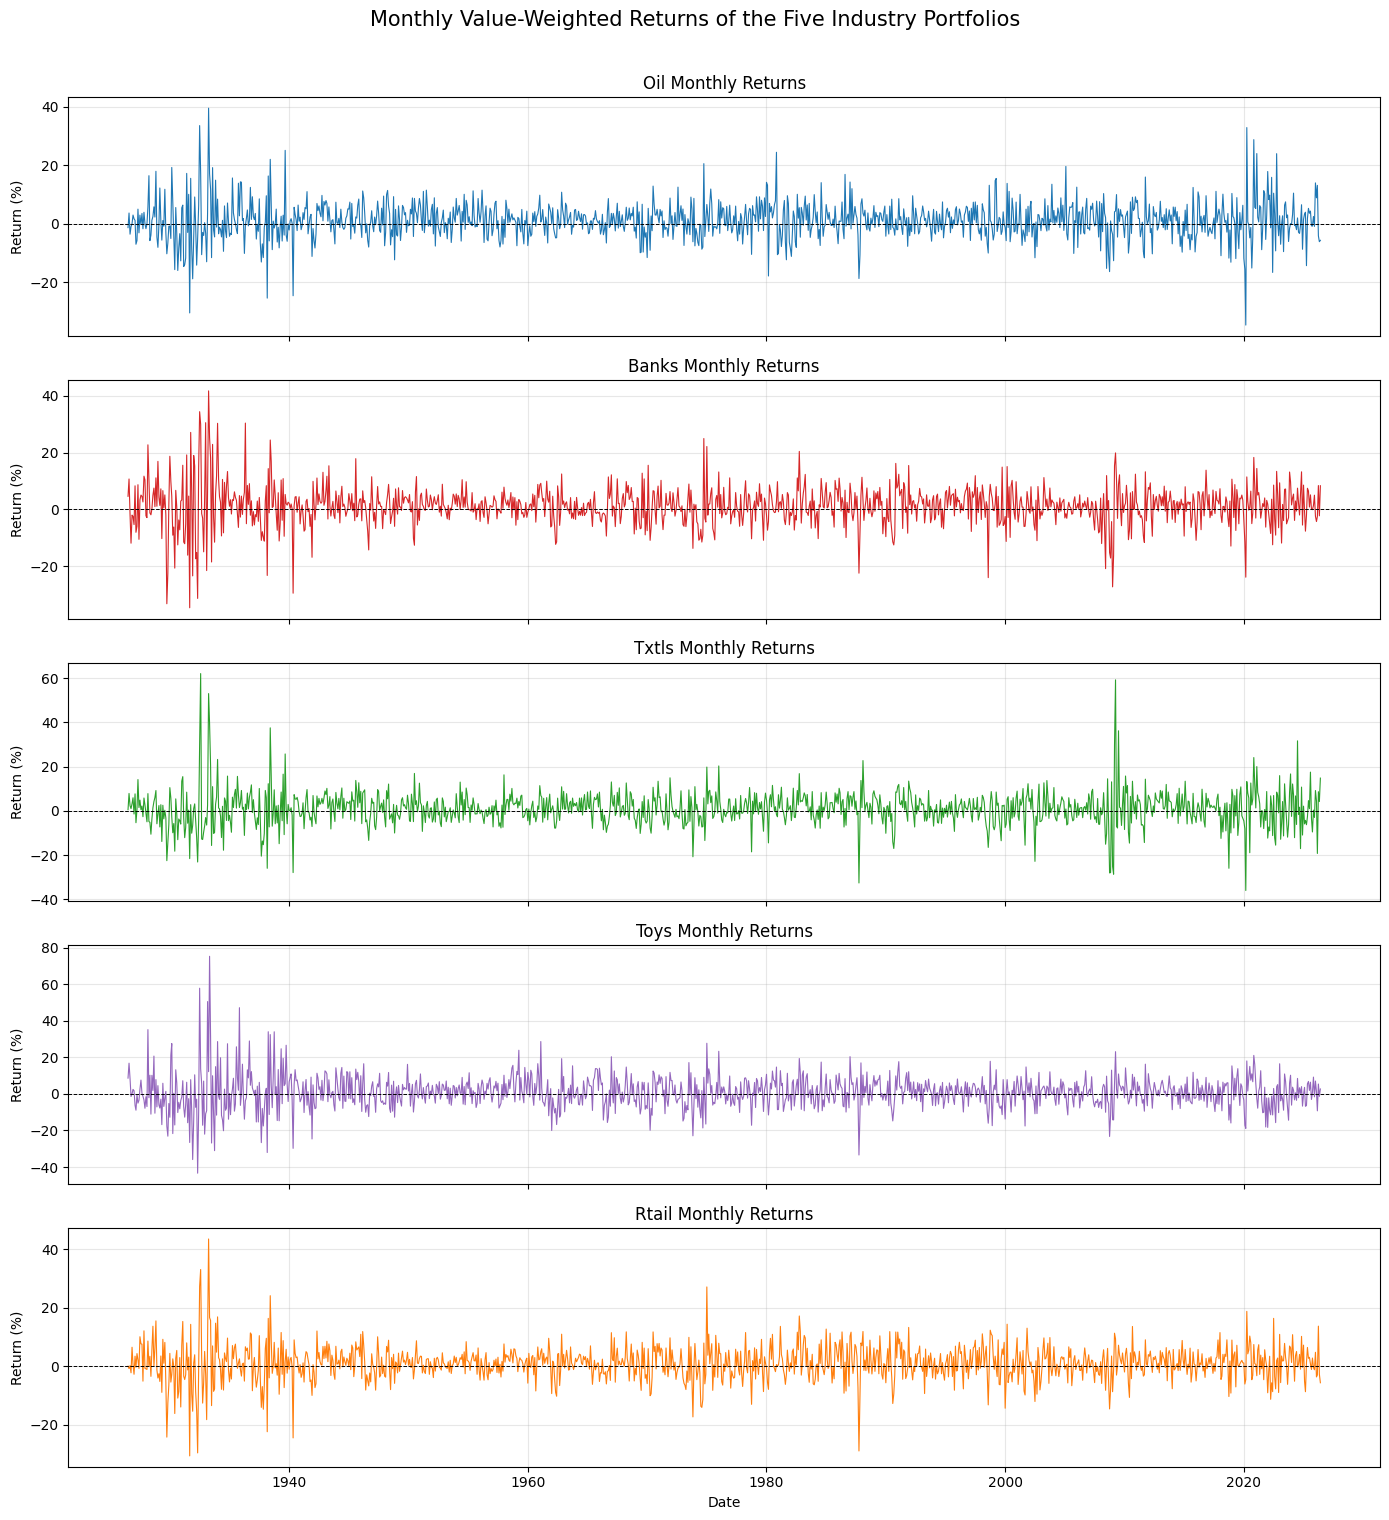

In [88]:


# Use the Datetime column or index for the horizontal axis
if "Datetime" in q2_data.columns:
    plot_dates = q2_data["Datetime"]
else:
    plot_dates = q2_data.index

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(14, 15),
    sharex=True
)

colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e"]

for ax, industry, color in zip(axes, industries, colors):

    ax.plot(
        plot_dates,
        q2_data[industry],
        color=color,
        linewidth=0.8
    )

    ax.axhline(
        y=0,
        color="black",
        linewidth=0.7,
        linestyle="--"
    )

    ax.set_title(f"{industry} Monthly Returns")
    ax.set_ylabel("Return (%)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")

fig.suptitle(
    "Monthly Value-Weighted Returns of the Five Industry Portfolios",
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

In [89]:
# Five Fama–French factors
factors = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

# Prepare the factor dataset
factor_data = FF5[["Date"] + factors].copy()

# Convert values to numeric
factor_data = factor_data.apply(
    pd.to_numeric,
    errors="coerce"
)

# Remove invalid dates
factor_data = factor_data.dropna(subset=["Date"])
factor_data["Date"] = factor_data["Date"].astype(int)

# Retain only valid monthly YYYYMM observations
valid_month = factor_data["Date"] % 100

factor_data = factor_data[
    valid_month.between(1, 12)
].copy()

# Ensure each month appears only once
factor_data = (
    factor_data
    .drop_duplicates(subset="Date", keep="first")
    .sort_values("Date")
    .reset_index(drop=True)
)

# Convert YYYYMM into a datetime
factor_data["Datetime"] = pd.to_datetime(
    factor_data["Date"].astype(str),
    format="%Y%m"
)

print(
    "Factor sample:",
    factor_data["Date"].min(),
    "to",
    factor_data["Date"].max()
)

print(
    "Number of observations:",
    len(factor_data)
)

Factor sample: 196307 to 202606
Number of observations: 756


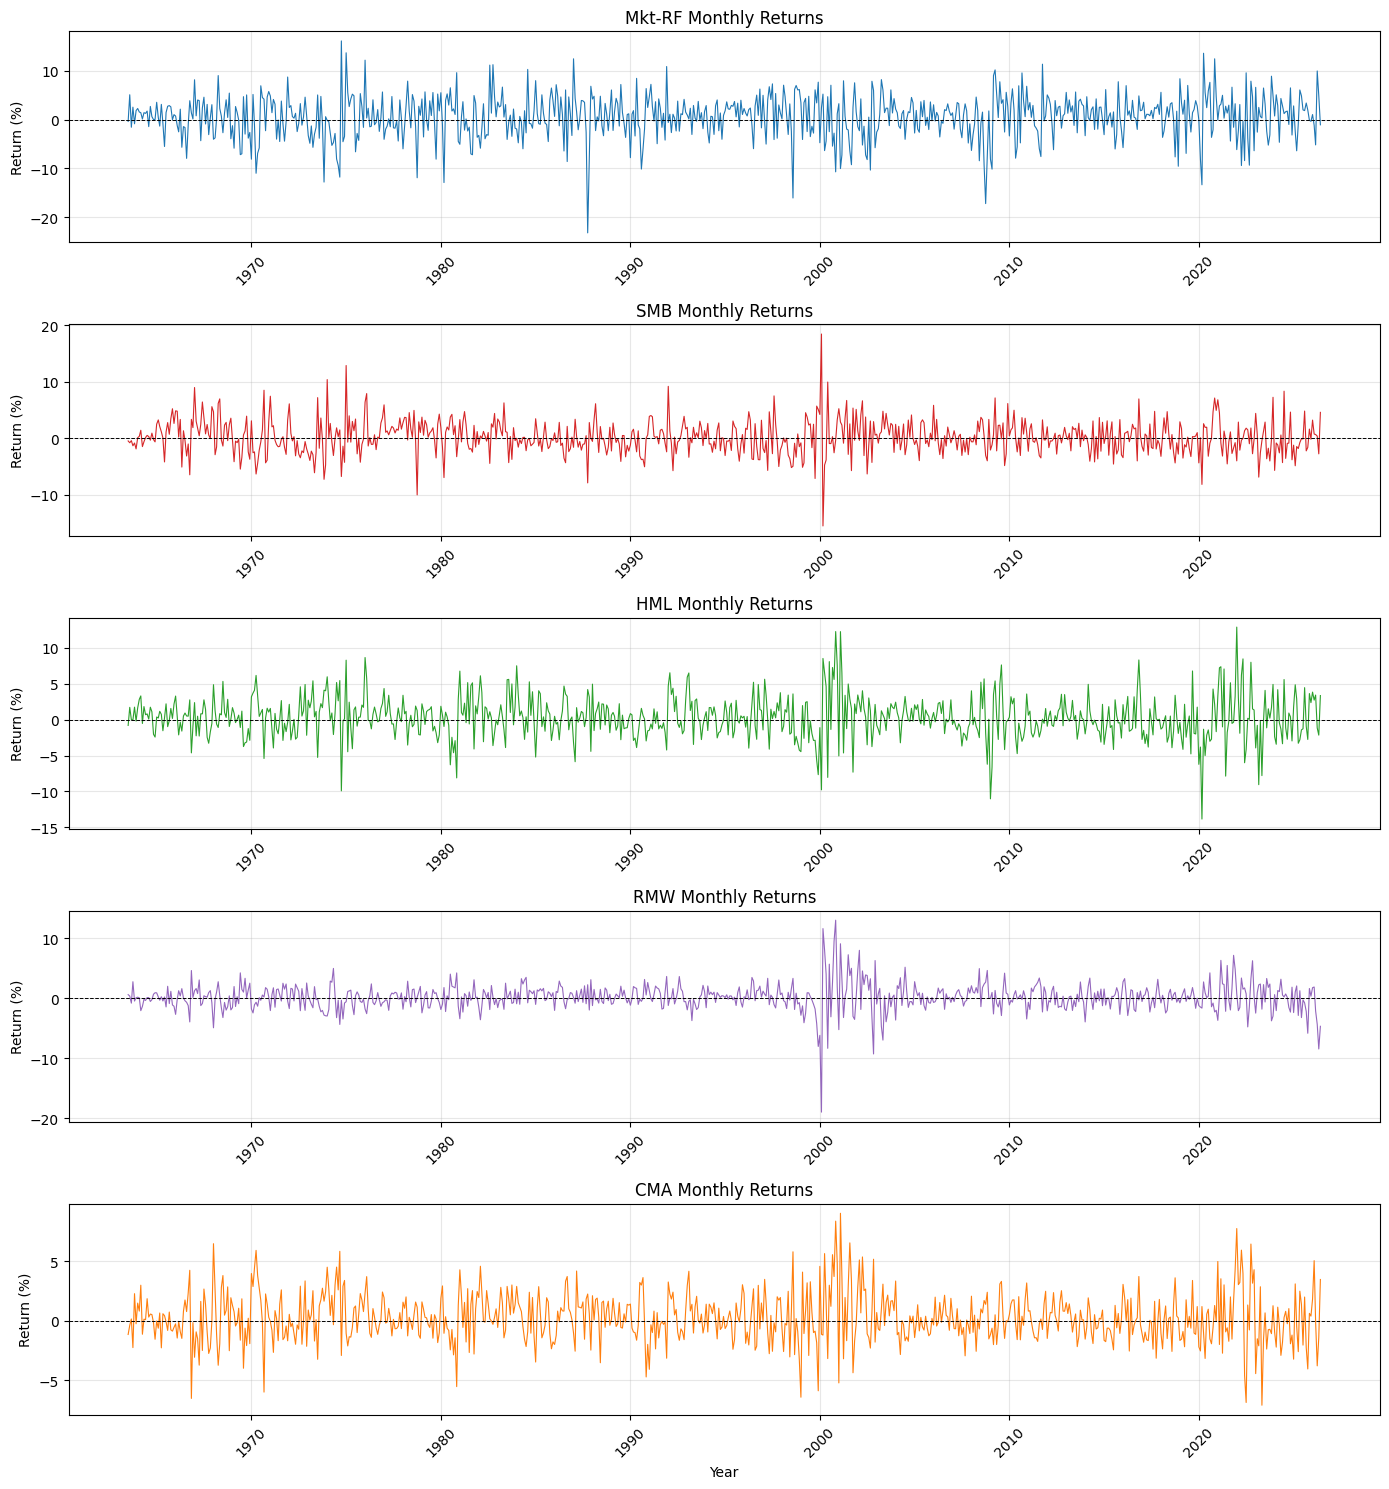

In [106]:
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(14, 15),
    sharex=True
)

colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e"]

for ax, factor, color in zip(axes, factors, colors):

    ax.plot(
        factor_data["Datetime"],
        factor_data[factor],
        color=color,
        linewidth=0.8
    )

    ax.axhline(
        y=0,
        color="black",
        linewidth=0.7,
        linestyle="--"
    )

    ax.set_title(f"{factor} Monthly Returns")
    ax.set_ylabel("Return (%)")
    ax.grid(True, alpha=0.3)

    # Show one year label every 10 years
    ax.xaxis.set_major_locator(
        mdates.YearLocator(10)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

    ax.tick_params(
        axis="x",
        labelbottom=True,
        labelrotation=45
    )

axes[-1].set_xlabel("Year")

plt.tight_layout()
plt.show()

Testing for residual autocorrelation:

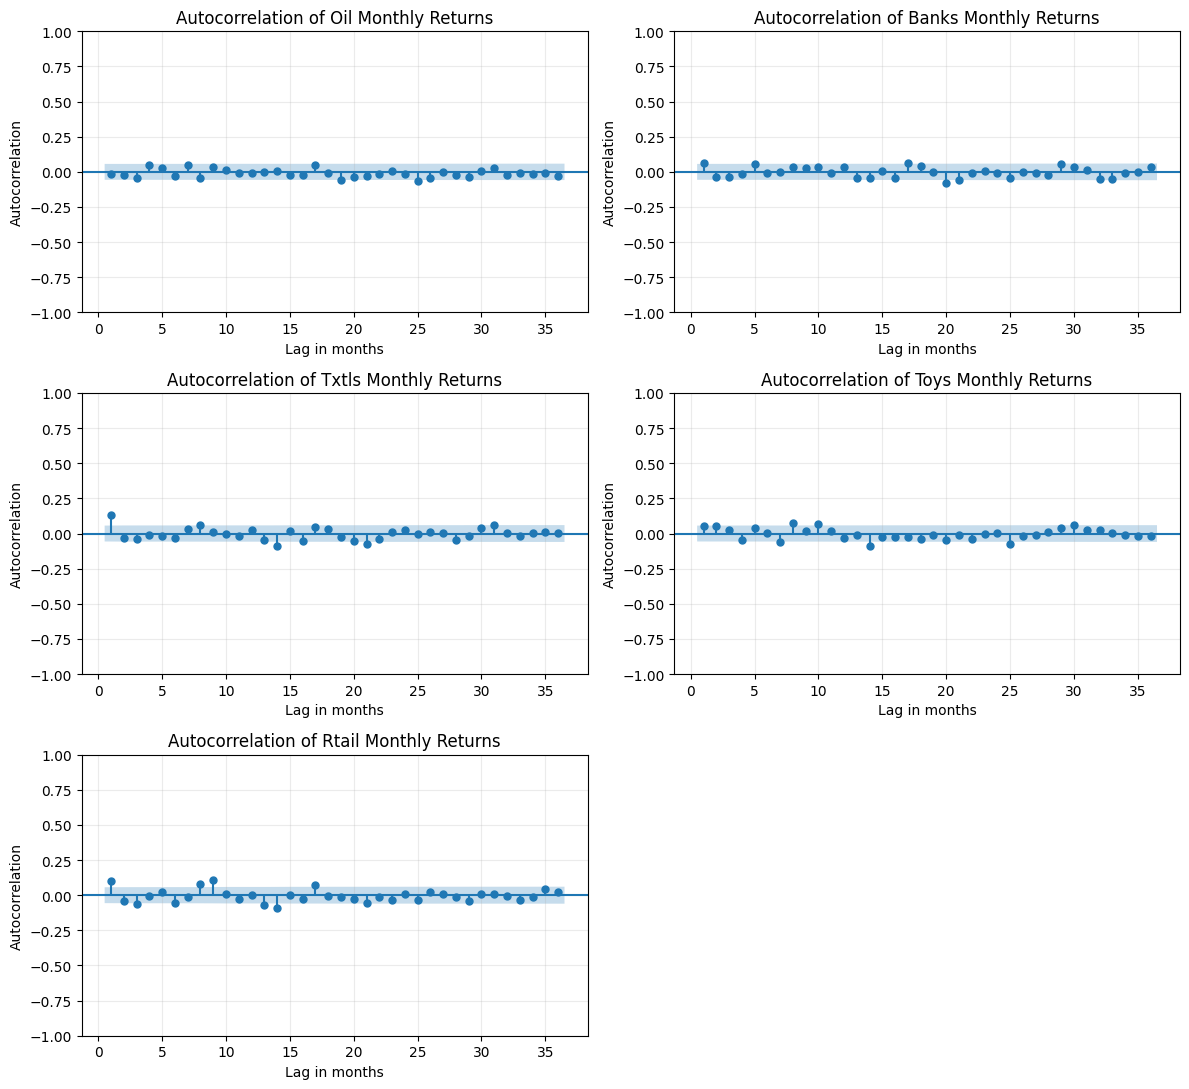

In [107]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 11)
)

axes = axes.flatten()

for ax, industry in zip(
    axes,
    industries
):

    industry_returns = (
        q2_data[industry]
        .dropna()
    )

    plot_acf(
        industry_returns,
        lags=36,
        zero=False,
        alpha=0.05,
        ax=ax
    )

    ax.set_title(
        f"Autocorrelation of {industry} Monthly Returns"
    )

    ax.set_xlabel("Lag in months")
    ax.set_ylabel("Autocorrelation")
    ax.grid(alpha=0.25)

# There are six panels but only five industries
axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [108]:
ljung_box_results = []

for industry in industries:

    industry_returns = (
        q2_data[industry]
        .dropna()
    )

    test_results = acorr_ljungbox(
        industry_returns,
        lags=[12, 24, 36],
        return_df=True
    )

    for lag in [12, 24, 36]:

        ljung_box_results.append({
            "Industry": industry,
            "Lags": lag,
            "Q-statistic": test_results.loc[
                lag,
                "lb_stat"
            ],
            "p-value": test_results.loc[
                lag,
                "lb_pvalue"
            ]
        })

ljung_box_results = pd.DataFrame(
    ljung_box_results
)

display(
    ljung_box_results.round(4)
)

print(
    ljung_box_results.to_string(
        index=False
    )
)

,Industry,Lags,Q-statistic,p-value
0,Oil,12,15.1084,0.2356
1,Oil,24,26.4956,0.3285
2,Oil,36,40.1428,0.2916
3,Banks,12,18.8017,0.0934
4,Banks,24,44.2338,0.0072
5,Banks,36,60.6170,0.0063
6,Txtls,12,32.4000,0.0012
7,Txtls,24,64.6738,0.0000
8,Txtls,36,74.5050,0.0002
9,Toys,12,32.2135,0.0013


Industry  Lags  Q-statistic      p-value
     Oil    12    15.108354 2.355643e-01
     Oil    24    26.495633 3.285053e-01
     Oil    36    40.142783 2.916350e-01
   Banks    12    18.801686 9.342805e-02
   Banks    24    44.233814 7.166274e-03
   Banks    36    60.617022 6.289379e-03
   Txtls    12    32.400006 1.200058e-03
   Txtls    24    64.673752 1.358846e-05
   Txtls    36    74.504986 1.696089e-04
    Toys    12    32.213476 1.282587e-03
    Toys    24    50.507692 1.219722e-03
    Toys    36    66.667546 1.408696e-03
   Rtail    12    47.636205 3.615737e-06
   Rtail    24    78.791244 9.468334e-08
   Rtail    36    88.735610 2.406700e-06


In [109]:
from statsmodels.tsa.stattools import acf


significant_lags = []

for industry in industries:

    industry_returns = (
        q2_data[industry]
        .dropna()
    )

    acf_values, confidence_intervals = acf(
        industry_returns,
        nlags=36,
        alpha=0.05,
        fft=True
    )

    # Begin at lag 1 because lag 0 always equals one
    for lag in range(1, 37):

        lower_bound = confidence_intervals[lag, 0]
        upper_bound = confidence_intervals[lag, 1]

        # Significant if the confidence interval excludes zero
        is_significant = (
            lower_bound > 0
            or upper_bound < 0
        )

        if is_significant:

            significant_lags.append({
                "Industry": industry,
                "Lag": lag,
                "ACF": acf_values[lag],
                "Lower 95% CI": lower_bound,
                "Upper 95% CI": upper_bound
            })


significant_lags = pd.DataFrame(
    significant_lags
)

display(
    significant_lags.round(4)
)

,Industry,Lag,ACF,Lower 95% CI,Upper 95% CI
0,Oil,19,-0.0586,-0.1161,-0.0011
1,Oil,25,-0.0672,-0.1250,-0.0094
2,Banks,1,0.0659,0.0093,0.1224
3,Banks,5,0.0592,0.0022,0.1162
4,Banks,17,0.0633,0.0055,0.1210
5,Banks,20,-0.0783,-0.1364,-0.0203
6,Banks,21,-0.0614,-0.1197,-0.0030
7,Txtls,1,0.1320,0.0754,0.1886
8,Txtls,8,0.0592,0.0014,0.1171
9,Txtls,14,-0.0865,-0.1447,-0.0283


In [110]:
for industry in industries:

    industry_results = significant_lags[
        significant_lags["Industry"] == industry
    ]

    print(f"\n{industry}")

    if industry_results.empty:
        print("No individually significant lags.")

    else:
        for _, row in industry_results.iterrows():

            direction = (
                "positive"
                if row["ACF"] > 0
                else "negative"
            )

            print(
                f"Lag {int(row['Lag'])}: "
                f"ACF = {row['ACF']:.4f} "
                f"({direction})"
            )


Oil
Lag 19: ACF = -0.0586 (negative)
Lag 25: ACF = -0.0672 (negative)

Banks
Lag 1: ACF = 0.0659 (positive)
Lag 5: ACF = 0.0592 (positive)
Lag 17: ACF = 0.0633 (positive)
Lag 20: ACF = -0.0783 (negative)
Lag 21: ACF = -0.0614 (negative)

Txtls
Lag 1: ACF = 0.1320 (positive)
Lag 8: ACF = 0.0592 (positive)
Lag 14: ACF = -0.0865 (negative)
Lag 21: ACF = -0.0727 (negative)

Toys
Lag 7: ACF = -0.0603 (negative)
Lag 8: ACF = 0.0732 (positive)
Lag 10: ACF = 0.0697 (positive)
Lag 14: ACF = -0.0886 (negative)
Lag 25: ACF = -0.0721 (negative)

Rtail
Lag 1: ACF = 0.1040 (positive)
Lag 3: ACF = -0.0653 (negative)
Lag 6: ACF = -0.0580 (negative)
Lag 8: ACF = 0.0782 (positive)
Lag 9: ACF = 0.1095 (positive)
Lag 13: ACF = -0.0732 (negative)
Lag 14: ACF = -0.0903 (negative)
Lag 17: ACF = 0.0744 (positive)


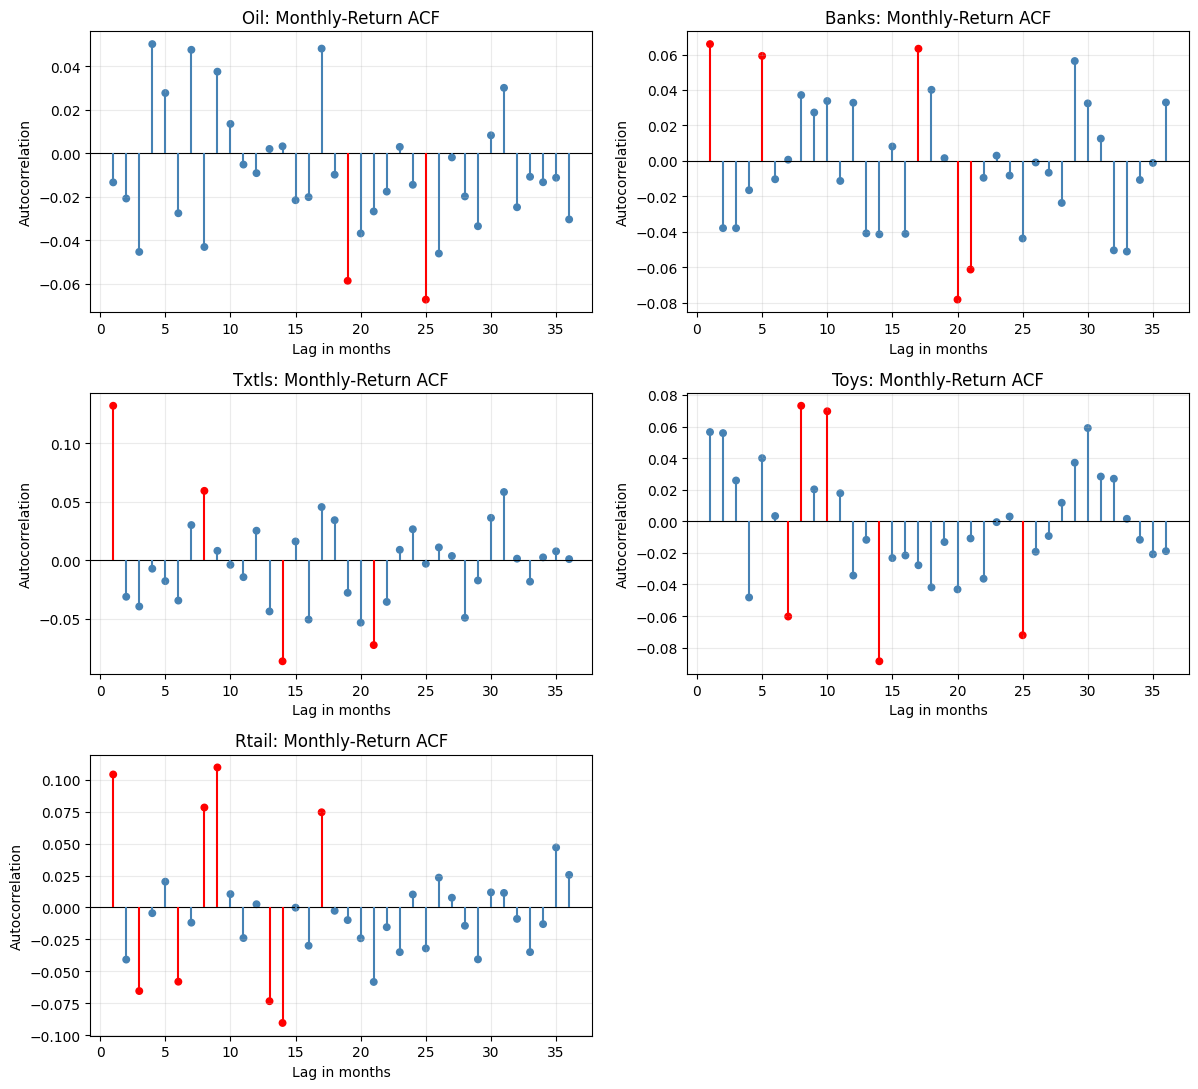

In [111]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 11)
)

axes = axes.flatten()

for ax, industry in zip(
    axes,
    industries
):

    industry_returns = (
        q2_data[industry]
        .dropna()
    )

    acf_values, confidence_intervals = acf(
        industry_returns,
        nlags=36,
        alpha=0.05,
        fft=True
    )

    lags = np.arange(1, 37)
    values = acf_values[1:]

    lower = confidence_intervals[1:, 0]
    upper = confidence_intervals[1:, 1]

    significant = (
        (lower > 0) |
        (upper < 0)
    )

    colors = np.where(
        significant,
        "red",
        "steelblue"
    )

    ax.axhline(
        0,
        color="black",
        linewidth=0.8
    )

    ax.vlines(
        lags,
        0,
        values,
        colors=colors,
        linewidth=1.5
    )

    ax.scatter(
        lags,
        values,
        color=colors,
        s=22
    )

    ax.set_title(
        f"{industry}: Monthly-Return ACF"
    )

    ax.set_xlabel("Lag in months")
    ax.set_ylabel("Autocorrelation")
    ax.grid(alpha=0.25)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [112]:
q3_data = q2_data.copy()

q3_data["Year"] = q3_data["Date"] // 100
q3_data["Month"] = q3_data["Date"] % 100

q3_data["January"] = (
    q3_data["Month"] == 1
).astype(int)

# Entire available value-weighted sample
main_sample = q3_data.copy()

print(
    "Full sample:",
    main_sample["Date"].min(),
    "to",
    main_sample["Date"].max()
)

print(
    "Number of observations:",
    len(main_sample)
)

Full sample: 192607 to 202606
Number of observations: 1200


In [113]:
residual_test_results = []

for industry in industries:

    regression_data = main_sample[
        [industry, "January"]
    ].dropna()

    y = regression_data[industry]

    X = sm.add_constant(
        regression_data["January"]
    )

    # Ordinary regression: residuals do not depend on
    # the standard-error estimator
    model = sm.OLS(y, X).fit()

    residual_test = acorr_ljungbox(
        model.resid,
        lags=[12],
        return_df=True
    )

    residual_test_results.append({
        "Industry": industry,
        "Residual Q-statistic": residual_test.loc[
            12,
            "lb_stat"
        ],
        "Residual p-value": residual_test.loc[
            12,
            "lb_pvalue"
        ]
    })

residual_test_results = pd.DataFrame(
    residual_test_results
)

display(
    residual_test_results.round(4)
)

,Industry,Residual Q-statistic,Residual p-value
0,Oil,14.9914,0.2419
1,Banks,18.8966,0.0911
2,Txtls,32.6056,0.0011
3,Toys,31.9437,0.0014
4,Rtail,48.4880,0.0000


To determine the appropriate standard errors for the January-effect regressions, we applied the Ljung–Box test to the regression residuals using 12 monthly lags. The null hypothesis is that the residuals have no serial correlation through lag 12. We fail to reject this hypothesis for Oil (\(p=0.242\)) and Banks (\(p=0.091\)) at the 5% level, although the result for Banks is marginal at 10%. In contrast, the null is strongly rejected for Textiles (\(p=0.001\)), Toys (\(p=0.001\)), and Retail (\(p<0.001\)), indicating that their residuals remain serially correlated. Consequently, conventional or purely heteroskedasticity-robust standard errors may produce unreliable inference for several portfolios. We therefore use Newey–West HAC standard errors for all five regressions, as these account for both heteroskedasticity and serial correlation and provide a consistent basis for comparison across industries.


Estimate now: Ri,t=αi,0+αi,J​ Januaryt+εi,t

In [114]:
industries = [
    "Oil",
    "Banks",
    "Txtls",
    "Toys",
    "Rtail"
]

q3_data = q2_data.copy()

q3_data["Year"] = q3_data["Date"] // 100
q3_data["Month"] = q3_data["Date"] % 100

q3_data["January"] = (
    q3_data["Month"] == 1
).astype(int)
months_per_year = (
    q3_data.groupby("Year")["Month"]
    .nunique()
)

complete_years = months_per_year[
    months_per_year == 12
].index

q3_data = q3_data[
    q3_data["Year"].isin(complete_years)
].copy()

print(
    "Question 3 sample:",
    q3_data["Date"].min(),
    "to",
    q3_data["Date"].max()
)

print(
    "Observations:",
    len(q3_data)
)

print(
    "January observations:",
    q3_data["January"].sum()
)

Question 3 sample: 192701 to 202512
Observations: 1188
January observations: 99


In [115]:
def estimate_january_effect(
    sample,
    industry
):
    """
    Estimate:
    R_it = alpha_0 + alpha_J * January_t + error_t
    """

    regression_data = sample[
        [industry, "January"]
    ].dropna()

    y = regression_data[industry]

    X = sm.add_constant(
        regression_data["January"]
    )

    # Newey-West standard errors with 12 monthly lags
    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 12}
    )

    alpha_0 = model.params["const"]
    alpha_january = model.params["January"]

    return {
        "Industry": industry,
        "Observations": int(model.nobs),
        "Non-January mean": alpha_0,
        "t(alpha_0)": model.tvalues["const"],
        "January effect": alpha_january,
        "HAC SE": model.bse["January"],
        "t(January effect)": model.tvalues["January"],
        "p-value": model.pvalues["January"],
        "January mean": alpha_0 + alpha_january,
        "R-squared": model.rsquared
    }

Full sample results

In [116]:
full_sample_results = pd.DataFrame([
    estimate_january_effect(
        q3_data,
        industry
    )
    for industry in industries
])

display(
    full_sample_results.round({
        "Non-January mean": 3,
        "t(alpha_0)": 3,
        "January effect": 3,
        "HAC SE": 3,
        "t(January effect)": 3,
        "p-value": 4,
        "January mean": 3,
        "R-squared": 4
    })
)

,Industry,Observations,Non-January mean,t(alpha_0),January effect,HAC SE,t(January effect),p-value,January mean,R-squared
0,Oil,1188,1.064,5.826,-0.439,0.589,-0.746,0.4556,0.624,0.0004
1,Banks,1188,1.038,4.746,1.509,0.819,1.843,0.0654,2.546,0.0035
2,Txtls,1188,0.744,2.852,1.878,0.787,2.387,0.0170,2.623,0.0043
3,Toys,1188,0.779,2.492,1.388,0.948,1.465,0.1430,2.167,0.0017
4,Rtail,1188,1.036,5.367,0.350,0.648,0.541,0.5888,1.386,0.0003


In [117]:
full_sample_results["Holm p-value"] = multipletests(
    full_sample_results["p-value"],
    method="holm"
)[1]

full_sample_results[
    "Significant at 5%"
] = np.where(
    full_sample_results["p-value"] < 0.05,
    "Yes",
    "No"
)

full_sample_results[
    "Significant after Holm"
] = np.where(
    full_sample_results["Holm p-value"] < 0.05,
    "Yes",
    "No"
)

display(
    full_sample_results[
        [
            "Industry",
            "Non-January mean",
            "January effect",
            "HAC SE",
            "t(January effect)",
            "p-value",
            "Holm p-value",
            "January mean",
            "Significant at 5%",
            "Significant after Holm"
        ]
    ].round(4)
)

,Industry,Non-January mean,January effect,HAC SE,t(January effect),p-value,Holm p-value,January mean,Significant at 5%,Significant after Holm
0,Oil,1.0635,-0.4393,0.5888,-0.7460,0.4556,0.9113,0.6242,No,No
1,Banks,1.0378,1.5086,0.8186,1.8428,0.0654,0.2614,2.5464,No,No
2,Txtls,0.7440,1.8785,0.7870,2.3870,0.0170,0.0849,2.6225,Yes,No
3,Toys,0.7786,1.3880,0.9477,1.4647,0.1430,0.4290,2.1666,No,No
4,Rtail,1.0355,0.3502,0.6477,0.5406,0.5888,0.9113,1.3857,No,No


In [118]:
first_year = int(q3_data["Year"].min())
last_year = int(q3_data["Year"].max())

periods = {}

for period_start in range(
    first_year,
    last_year + 1,
    10
):
    period_end = min(
        period_start + 9,
        last_year
    )

    # Exclude extremely short final periods
    if period_end - period_start + 1 >= 5:

        period_name = (
            f"{period_start}-{period_end}"
        )

        periods[period_name] = (
            period_start,
            period_end
        )

print(periods)

{'1927-1936': (1927, 1936), '1937-1946': (1937, 1946), '1947-1956': (1947, 1956), '1957-1966': (1957, 1966), '1967-1976': (1967, 1976), '1977-1986': (1977, 1986), '1987-1996': (1987, 1996), '1997-2006': (1997, 2006), '2007-2016': (2007, 2016), '2017-2025': (2017, 2025)}


In [119]:
subperiod_results = []

for period_name, (
    period_start,
    period_end
) in periods.items():

    period_sample = q3_data[
        q3_data["Year"].between(
            period_start,
            period_end
        )
    ].copy()

    for industry in industries:

        result = estimate_january_effect(
            period_sample,
            industry
        )

        result["Period"] = period_name

        subperiod_results.append(result)


subperiod_results = pd.DataFrame(
    subperiod_results
)

In [120]:
subperiod_results["Holm p-value"] = (
    subperiod_results
    .groupby("Period")["p-value"]
    .transform(
        lambda p_values: multipletests(
            p_values,
            method="holm"
        )[1]
    )
)

display(
    subperiod_results[
        [
            "Period",
            "Industry",
            "Observations",
            "Non-January mean",
            "January effect",
            "HAC SE",
            "t(January effect)",
            "p-value",
            "Holm p-value",
            "January mean"
        ]
    ].round(4)
)

,Period,Industry,Observations,Non-January mean,January effect,HAC SE,t(January effect),p-value,Holm p-value,January mean
0,1927-1936,Oil,120,0.8765,-0.2505,2.3162,-0.1081,0.9139,1.0000,0.6260
1,1927-1936,Banks,120,1.6185,10.0795,4.1555,2.4255,0.0153,0.0764,11.6980
2,1927-1936,Txtls,120,0.2362,4.5988,3.1614,1.4547,0.1458,0.5830,4.8350
3,1927-1936,Toys,120,0.3993,-1.0133,3.9336,-0.2576,0.7967,1.0000,-0.6140
4,1927-1936,Rtail,120,0.9655,0.1285,2.5242,0.0509,0.9594,1.0000,1.0940
5,1937-1946,Oil,120,0.7434,-0.5124,1.0714,-0.4782,0.6325,1.0000,0.2310
6,1937-1946,Banks,120,0.6283,1.4947,1.6369,0.9131,0.3612,1.0000,2.1230
7,1937-1946,Txtls,120,0.9375,2.8435,1.8655,1.5243,0.1274,0.6372,3.7810
8,1937-1946,Toys,120,1.3252,1.1768,3.0284,0.3886,0.6976,1.0000,2.5020
9,1937-1946,Rtail,120,0.8715,0.8775,1.4714,0.5963,0.5510,1.0000,1.7490


In [121]:
subperiod_results["Estimate (t-stat)"] = (
    subperiod_results["January effect"]
    .map(lambda value: f"{value:.3f}")
    +
    subperiod_results["t(January effect)"]
    .map(lambda value: f" ({value:.2f})")
)

robustness_table = subperiod_results.pivot(
    index="Period",
    columns="Industry",
    values="Estimate (t-stat)"
)

display(robustness_table)


Industry,Banks,Oil,Rtail,Toys,Txtls
Period,,,,,
1927-1936,10.079 (2.43),-0.250 (-0.11),0.129 (0.05),-1.013 (-0.26),4.599 (1.45)
1937-1946,1.495 (0.91),-0.512 (-0.48),0.877 (0.60),1.177 (0.39),2.844 (1.52)
1947-1956,-0.206 (-0.24),-1.274 (-0.84),-0.631 (-0.84),1.667 (1.08),0.383 (0.33)
1957-1966,-0.316 (-0.25),0.189 (0.16),-0.888 (-0.61),1.754 (0.61),4.920 (2.63)
1967-1976,3.641 (1.22),-0.693 (-0.41),4.716 (1.54),6.861 (1.60),6.127 (2.04)
1977-1986,-0.916 (-0.70),-0.903 (-0.39),-1.311 (-0.70),0.330 (0.14),1.667 (1.32)
1987-1996,3.502 (2.00),1.534 (0.80),1.778 (1.07),3.681 (1.68),0.887 (0.47)
1997-2006,-0.951 (-0.99),-1.537 (-0.91),-1.482 (-0.79),1.165 (0.64),-0.996 (-0.65)
2007-2016,-3.768 (-1.17),-2.623 (-1.53),-2.040 (-1.31),-3.091 (-1.44),-3.577 (-1.10)
